# Case Study: Monopolistic Pricing

This notebook reproduces **Figures 6, 7, and 9** from Chan, Chen, Fernandes, and Maaz (2025).

**Setting.** A monopolistic firm sells an indivisible good to customers whose willingness-to-pay $X$ is drawn i.i.d. from an unknown cdf $F_0$ supported on $[l, u] = [10, 60]$. Data is collected at three historical prices:

| Price | Role | Observations |
|-------|------|--------------|
| \$25 | Sale | 25 |
| \$35 | Regular | 75 |
| \$45 | High | 50 |

At price $p$, each customer buys if and only if their valuation exceeds $p$, so the sale probability is $1 - F_0(p)$ and the expected revenue is $\mathcal{R}(p) = p(1 - F_0(p))$. The oracle optimal price is $p^* = \arg\max_{p \in [l,u]} p(1 - F_0(p))$.

**Estimate-then-optimize strategy.** Each method constructs an estimate $\hat{F}$, then sets
$$\hat{p} = \arg\max_{p \in [l,u]}\; p(1 - \hat{F}(p)).$$
Performance is measured by the **revenue ratio**
$$\frac{\hat{p}(1 - F_0(\hat{p}))}{p^*(1 - F_0(p^*))} \in [0, 1],$$
where 1 is optimal. A non-IFR estimate $\hat{F}$ may produce a non-unimodal revenue curve, pushing $\hat{p}$ far from $p^*$.

**Three methods are compared:**
- **Algorithm 1 (Schumaker):** convex program in $t$-space, Schumaker interpolation; solved with CVXPY.
- **Discretized-IFR ($d=2$):** IFR enforced via bilinear (nonconvex) inequalities on a grid with $d=2$ points inserted between each pair of consecutive knots; solved with Gurobi.
- **Discretized-non-IFR:** monotonicity constraint only, no IFR; solved with Gurobi.

## Setup

Defines all imports, global constants, ground-truth distributions, and shared helpers.

**Key design decisions:**
- `DISTRIBUTIONS` is the single source of truth for all four ground-truth CDFs. Every experiment loops over it.
- `TruncatedDist` wraps any scipy distribution and normalizes it to $[l, u]$, enforcing $F(l) = 0$ and $F(u) = 1$ exactly via $\tilde{F}(x) = (F_\text{base}(x) - F_\text{base}(l)) / (F_\text{base}(u) - F_\text{base}(l))$.
- `method_labels` and `colors` are defined here and reused in every figure cell.
- `_l_inf_step` computes the $L^\infty$ error between a step CDF (returned by `fit_cdf_nonconvex`) and the true CDF; optionally restricted to $[l, x_k]$.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.stats import chi2, truncnorm, gamma as gamma_dist, logistic
from fitting import fit_cdf, fit_cdf_nonconvex
from tqdm.auto import tqdm
import os
import winsound

plt.rcParams.update({
    'axes.labelsize':  18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

os.makedirs('results', exist_ok=True)

# ── Problem parameters ──────────────────────────────────────────────────────────
l, u     = 10, 60.0
x_knots  = np.array([25.0, 35.0, 45.0])   # sale, regular, high prices
n_trials = np.array([25, 75, 50])          # observations at each price
x_knots  = np.array([25.0, 35.0, 45])   # sale, regular, high prices
n_trials = np.array([25, 75, 50])          # observations at each price
num_runs = 100
d_ifr    = 2   # Discretized-IFR grid density; d=2 matches Section 7.1 of paper

x_sym     = sp.Symbol('x')
x_fine    = np.linspace(l, u, 5000)
mask_knot = x_fine <= x_knots[-1]   # restrict to [l, x_k] for the Appendix figure

# ── Ground-truth distributions ──────────────────────────────────────────────────

class TruncatedDist:
    """Wraps a scipy distribution, normalizing CDF/PDF to [l, u].

    F_trunc(x) = (F_base(x) - F_base(l)) / (F_base(u) - F_base(l))
    """
    def __init__(self, base_dist, l, u):
        self._base = base_dist
        self.l, self.u = l, u
        self._Fl = base_dist.cdf(l)
        self._Fu = base_dist.cdf(u)

    def cdf(self, x):
        x = np.asarray(x, dtype=float)
        return np.clip((self._base.cdf(x) - self._Fl) / (self._Fu - self._Fl), 0.0, 1.0)

    def pdf(self, x):
        x = np.asarray(x, dtype=float)
        return np.where(
            (x >= self.l) & (x <= self.u),
            self._base.pdf(x) / (self._Fu - self._Fl),
            0.0,
        )


# Chi-squared(df=40) = Gamma(20, scale=2): IFR since shape=20 >= 1; opt price ~ 30
# Logistic(loc=38, s=5): IFR (hazard = F); untruncated opt satisfies F(p*)=s/p*=1/6, p*~30
DISTRIBUTIONS = {
    'ChiSq':    {'label': 'Chi-Sq (df=40)',
                 'display_name': 'Chi-Sq',
                 'dist': TruncatedDist(chi2(40), l, u)},
    'Normal':   {'label': 'Normal (mu=40, sigma=6)',
                 'display_name': 'Normal',
                 'dist': truncnorm((l - 40.0) / 6.0, (u - 40.0) / 6.0, loc=40.0, scale=6.0)},
    'Gamma':    {'label': 'Gamma (alpha=8, theta=6)',
                 'display_name': 'Gamma',
                 'dist': TruncatedDist(gamma_dist(8, scale=6), l, u)},
    'Logistic': {'label': 'Logistic (mu=36, s=5)',
                 'display_name': 'Logistic',
                 'dist': TruncatedDist(logistic(loc=36, scale=5), l, u)},
}

# ── Method styling (shared across all figure cells) ─────────────────────────────
method_keys_list = ['algo1', 'discretized_ifr', 'discretized_non_ifr']
method_labels = {
    'algo1':               'Algorithm 1 (Schumaker)',
    'discretized_ifr':     r'Discretized-IFR ($d=2$)',
    'discretized_non_ifr': 'Discretized-non-IFR',
}
colors = {'algo1': 'green', 'discretized_ifr': 'red', 'discretized_non_ifr': 'purple'}


def _l_inf_step(x_nc, F_nc, true_cdf_fn, x_max=None):
    """L-inf between a step CDF (fit_cdf_nonconvex output) and the true CDF.

    F_nc[k] is the step value on [x_nc[k], x_nc[k+1]).
    The supremum on each interval is at one of the endpoints (true CDF is monotone).
    If x_max is given, only intervals starting before x_max are included.
    """
    if x_max is not None:
        mask      = x_nc[:-1] < x_max
        step_vals = F_nc[:-1][mask]
        x_left    = x_nc[:-1][mask]
        x_right   = np.minimum(x_nc[1:][mask], x_max)
    else:
        step_vals = F_nc[:-1]
        x_left    = x_nc[:-1]
        x_right   = x_nc[1:]
    return float(np.max(np.maximum(
        np.abs(step_vals - true_cdf_fn(x_left)),
        np.abs(step_vals - true_cdf_fn(x_right)),
    )))

### Distribution Overview

Plots the PDF (top row) and CDF (bottom row) for each ground-truth distribution on $[l, u] = [0, 50]$. Red crosses mark the three knot positions $x_1 = 25$, $x_2 = 35$, $x_3 = 45$. Run this cell first to confirm each distribution has the intended shape and adequate mass in the interior of $[0, 50]$ before launching the Monte Carlo.

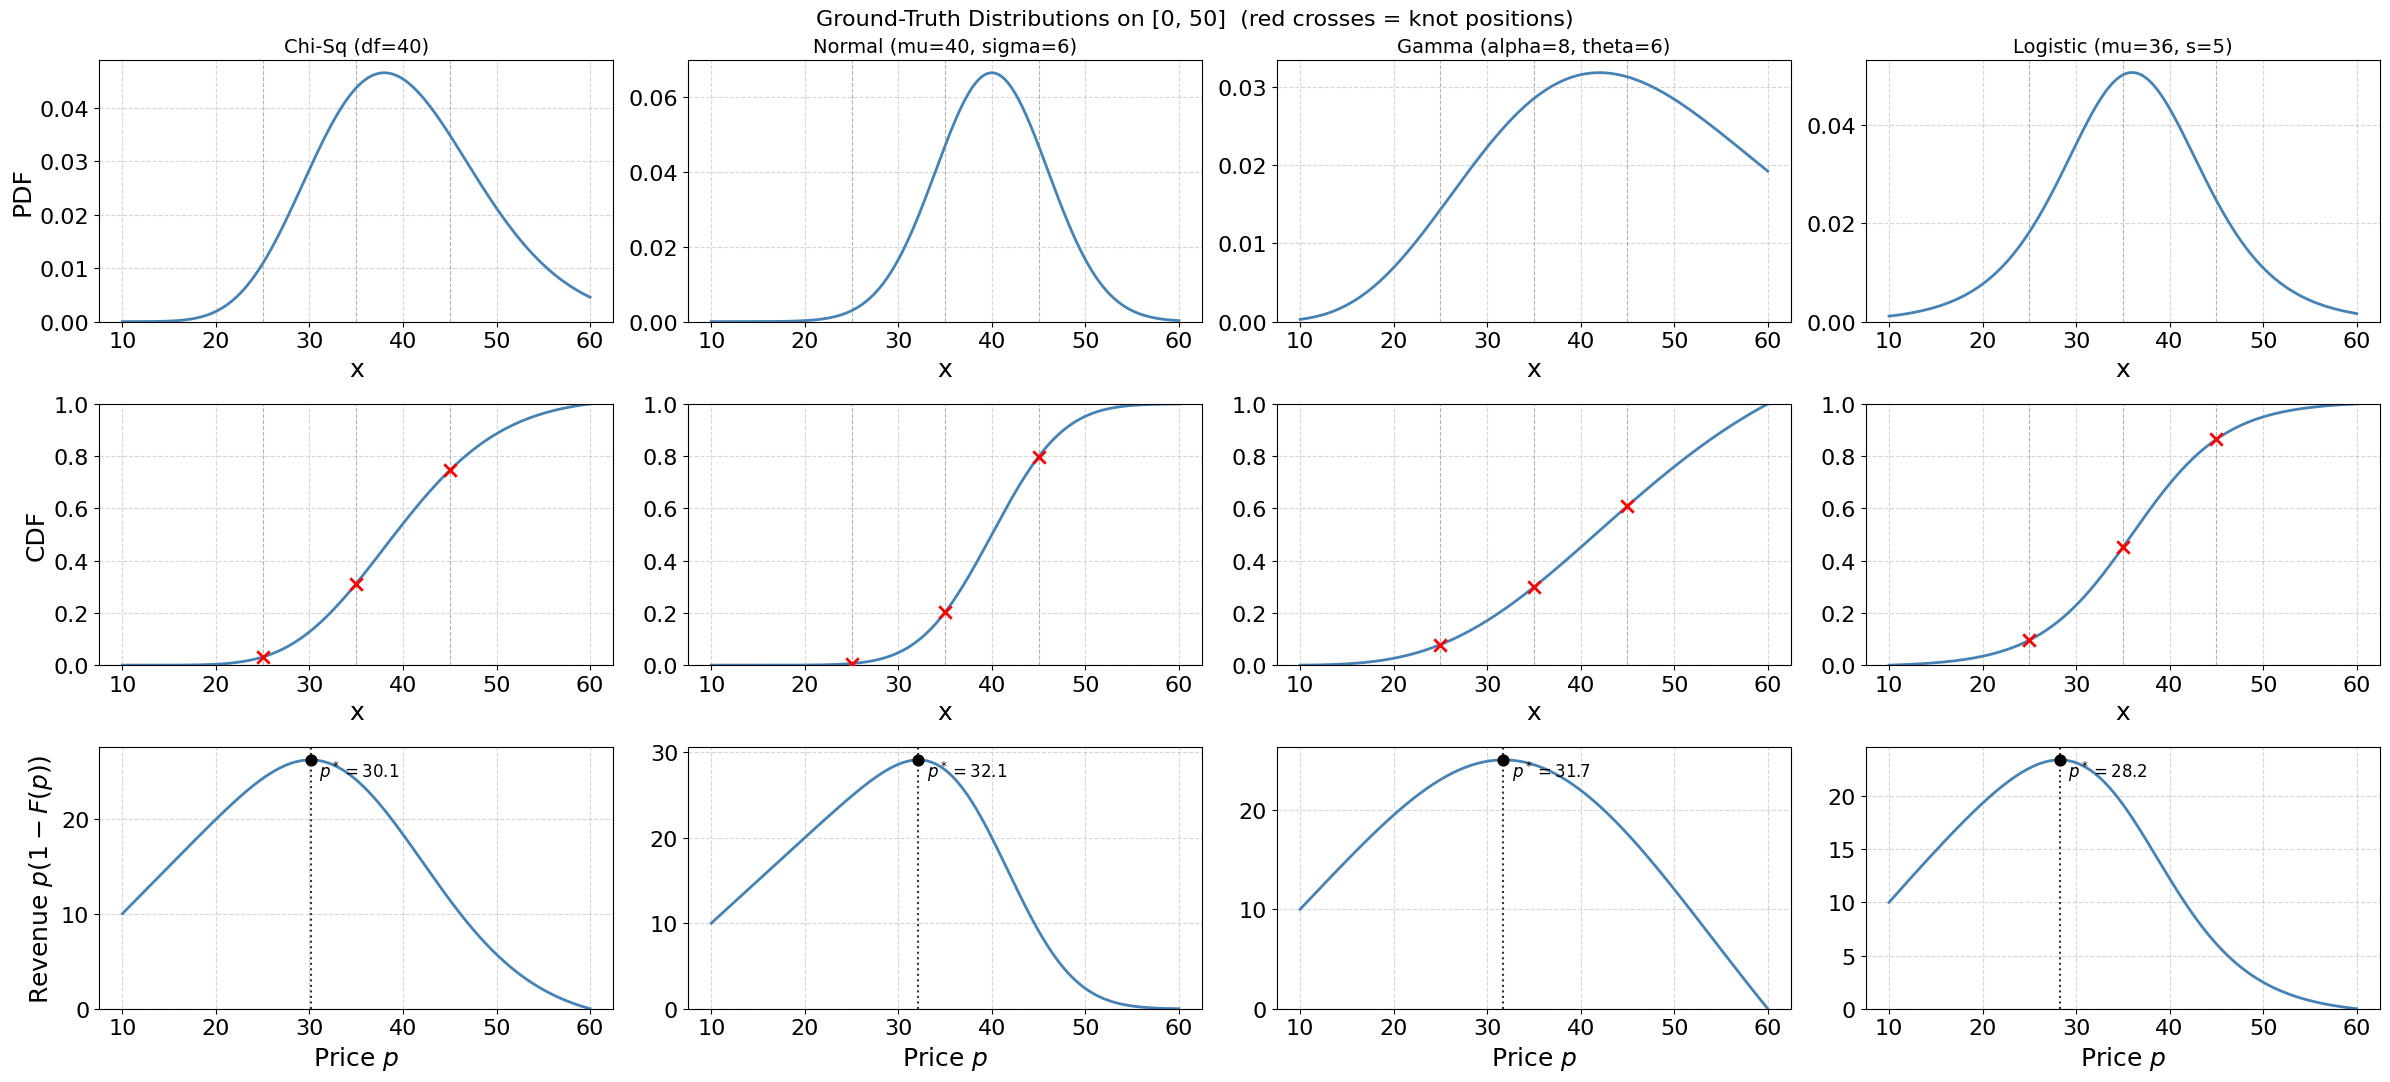

In [27]:
x_plot = np.linspace(l, u, 500)

fig, axes = plt.subplots(3, len(DISTRIBUTIONS), figsize=(6 * len(DISTRIBUTIONS), 11))

for j, (dist_key, dist_cfg) in enumerate(DISTRIBUTIONS.items()):
    dist     = dist_cfg['dist']
    pdf_vals = dist.pdf(x_plot)
    cdf_vals = dist.cdf(x_plot)
    rev_vals = x_plot * (1 - cdf_vals)

    opt_idx  = int(np.argmax(rev_vals))
    opt_p    = x_plot[opt_idx]
    opt_rev  = rev_vals[opt_idx]

    ax_pdf = axes[0, j]
    ax_cdf = axes[1, j]
    ax_rev = axes[2, j]

    ax_pdf.plot(x_plot, pdf_vals, color='steelblue', linewidth=2)
    for xk in x_knots:
        ax_pdf.axvline(xk, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax_pdf.set_title(dist_cfg['label'], fontsize=14)
    ax_pdf.set_xlabel('x')
    ax_pdf.set_ylim(bottom=0)
    ax_pdf.grid(True, ls='--', alpha=0.5)

    ax_cdf.plot(x_plot, cdf_vals, color='steelblue', linewidth=2)
    for xk in x_knots:
        ax_cdf.axvline(xk, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax_cdf.scatter([xk], [dist.cdf(np.array([xk]))],
                       color='red', zorder=5, s=80, marker='x', linewidths=2)
    ax_cdf.set_xlabel('x')
    ax_cdf.set_ylim(0, 1)
    ax_cdf.grid(True, ls='--', alpha=0.5)

    ax_rev.plot(x_plot, rev_vals, color='steelblue', linewidth=2)
    ax_rev.axvline(opt_p, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
    ax_rev.scatter([opt_p], [opt_rev], color='black', zorder=5, s=60)
    ax_rev.annotate(f'$p^*={opt_p:.1f}$', xy=(opt_p, opt_rev),
                    xytext=(6, -12), textcoords='offset points', fontsize=12)
    ax_rev.set_xlabel('Price $p$')
    ax_rev.set_ylim(bottom=0)
    ax_rev.grid(True, ls='--', alpha=0.5)

axes[0, 0].set_ylabel('PDF', fontsize=18)
axes[1, 0].set_ylabel('CDF', fontsize=18)
axes[2, 0].set_ylabel(r'Revenue $p(1-F(p))$', fontsize=18)

plt.suptitle('Ground-Truth Distributions on [0, 50]  (red crosses = knot positions)', fontsize=16)
plt.tight_layout()
plt.savefig('results/plots/pricing_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Computation

Runs `num_runs = 100` Monte Carlo replications for each of the four ground-truth distributions, computing three metrics per run:
- **Full $L^\infty$ error** $\|F_0 - \hat{F}\|_{[l,u]}$
- **Restricted $L^\infty$ error** $\|F_0 - \hat{F}\|_{[l, x_k]}$ (on the observed region only; used in Appendix A / Figure 9)
- **Revenue ratio** $\hat{p}(1 - F_0(\hat{p})) / p^*(1 - F_0(p^*))$

Results are stored in three arrays of shape `(n_dists, n_methods, num_runs)` and saved to `numerical_results/pricing_case_study.npz` so the figure cells can be run independently.

> **Note.** The Discretized-IFR and Discretized-non-IFR solvers require a Gurobi license. Algorithm 1 uses CVXPY and runs without Gurobi.

In [ ]:
np.random.seed(1)

dist_names_list = list(DISTRIBUTIONS.keys())
n_dists         = len(dist_names_list)
n_methods       = len(method_keys_list)
shape           = (n_dists, n_methods, num_runs)

all_errors      = np.full(shape, np.nan)
all_errors_knot = np.full(shape, np.nan)
all_revenues    = np.full(shape, np.nan)

for di, (dist_name, dist_cfg) in enumerate(DISTRIBUTIONS.items()):
    dist      = dist_cfg['dist']
    true_p    = dist.cdf(x_knots)
    true_fine = dist.cdf(x_fine)

    # True optimal price and revenue (oracle)
    true_rev      = x_fine * (1 - true_fine)
    true_opt_idx  = int(np.argmax(true_rev))
    true_opt_rev  = float(true_rev[true_opt_idx])
    print(f"{dist_name}: opt price = {x_fine[true_opt_idx]:.2f}, opt rev = {true_opt_rev:.4f}")

    true_fine_knot = true_fine[mask_knot]

    for run_idx in tqdm(range(num_runs), desc=dist_name, leave=False):
        y_samples = np.random.binomial(n_trials, true_p)

        # ── Algorithm 1 (Schumaker, CVXPY) ──────────────────────────────────────
        try:
            fitted = fit_cdf(x_knots, n_trials, y_samples, l, u, 'schumaker')
            fn     = sp.lambdify(x_sym, fitted, 'numpy')
            with np.errstate(invalid='ignore', over='ignore'):
                vals = np.array(fn(x_fine), dtype=float)
            vals = np.clip(np.where(np.isfinite(vals), vals, 1.0), 0, 1)
            all_errors[di, 0, run_idx]      = float(np.max(np.abs(vals - true_fine)))
            all_errors_knot[di, 0, run_idx] = float(np.max(np.abs(vals[mask_knot] - true_fine_knot)))
            opt_idx = int(np.argmax(x_fine * (1 - vals)))
            all_revenues[di, 0, run_idx] = float(x_fine[opt_idx] * (1 - true_fine[opt_idx])) / true_opt_rev
        except Exception as e:
            print(f"  [{dist_name}, run {run_idx}] algo1 failed: {e}")

        # ── Discretized-IFR (Gurobi, d=d_ifr) ───────────────────────────────────
        try:
            x_nc, F_nc = fit_cdf_nonconvex(
                x_knots, n_trials, y_samples, l, u, d_ifr,
                ifr_constraint=True, verbose=False, return_type='values',
            )
            all_errors[di, 1, run_idx]      = _l_inf_step(x_nc, F_nc, dist.cdf)
            all_errors_knot[di, 1, run_idx] = _l_inf_step(x_nc, F_nc, dist.cdf, x_max=x_knots[-1])
            F_nc_fine = F_nc[np.clip(np.searchsorted(x_nc, x_fine, side='right') - 1, 0, len(F_nc) - 1)]
            opt_idx = int(np.argmax(x_fine * (1 - F_nc_fine)))
            all_revenues[di, 1, run_idx] = float(x_fine[opt_idx] * (1 - true_fine[opt_idx])) / true_opt_rev
        except Exception as e:
            print(f"  [{dist_name}, run {run_idx}] discretized_ifr failed: {e}")

        # ── Discretized-non-IFR (Gurobi, monotonicity only) ─────────────────────
        try:
            x_ni, F_ni = fit_cdf_nonconvex(
                x_knots, n_trials, y_samples, l, u, 0,
                ifr_constraint=False, verbose=False, return_type='values',
            )
            all_errors[di, 2, run_idx]      = _l_inf_step(x_ni, F_ni, dist.cdf)
            all_errors_knot[di, 2, run_idx] = _l_inf_step(x_ni, F_ni, dist.cdf, x_max=x_knots[-1])
            F_ni_fine = F_ni[np.clip(np.searchsorted(x_ni, x_fine, side='right') - 1, 0, len(F_ni) - 1)]
            opt_idx = int(np.argmax(x_fine * (1 - F_ni_fine)))
            all_revenues[di, 2, run_idx] = float(x_fine[opt_idx] * (1 - true_fine[opt_idx])) / true_opt_rev
        except Exception as e:
            print(f"  [{dist_name}, run {run_idx}] discretized_non_ifr failed: {e}")

np.savez('results/data/pricing_case_study.npz',
    dist_names=np.array(dist_names_list),
    method_keys=np.array(method_keys_list),
    num_runs=num_runs,
    all_errors=all_errors,
    all_errors_knot=all_errors_knot,
    all_revenues=all_revenues,
)
print('Saved numerical_results/pricing_case_study.npz')

## Goodness-of-Fit

Loads `numerical_results/pricing_case_study.npz` and can be run independently of the computation cell.

- **Left panel:** full $L^\infty$ error $\|F_0 - \hat{F}\|_{[l,u]}$ over all runs. Tail extrapolation on $(x_k, u]$ can inflate Algorithm 1's error even when its fit on the observed region is superior.
- **Right panel:** restricted $L^\infty$ error $\|F_0 - \hat{F}\|_{[l, x_k]}$ on the observed region $[l, x_k] = [0, 45]$ only. Algorithm 1 consistently achieves the lowest error across all four distributions on this interval, confirming that the IFR constraint is well-exploited where data is available (Appendix A / Figure 9).

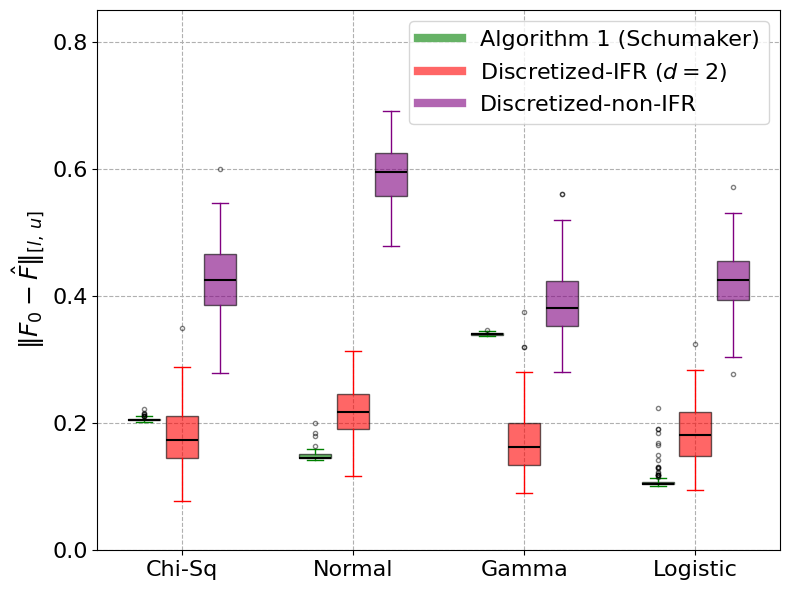

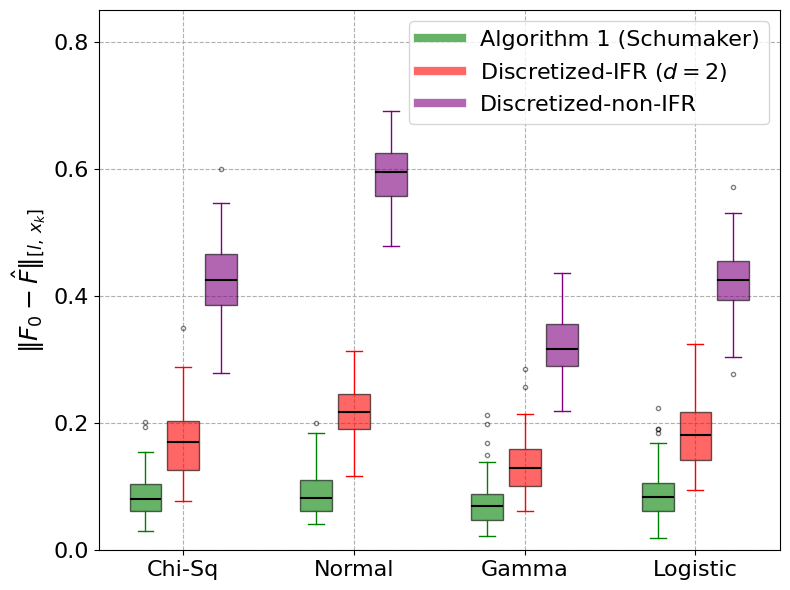

In [28]:
data = np.load('results/data/pricing_case_study.npz', allow_pickle=True)
dist_names_list  = data['dist_names'].tolist()
method_keys_list = data['method_keys'].tolist()
all_errors      = data['all_errors']       # (n_dists, n_methods, num_runs)
all_errors_knot = data['all_errors_knot']

n_dists   = len(dist_names_list)
n_methods = len(method_keys_list)
width     = 0.22
offsets   = np.linspace(-(n_methods - 1) * width / 2, (n_methods - 1) * width / 2, n_methods)
x_pos     = np.arange(n_dists)
display_names = [DISTRIBUTIONS[k]['display_name'] for k in dist_names_list]

def _add_boxplots(ax, arr_3d):
    """Grouped boxplots; arr_3d shape (n_dists, n_methods, num_runs)."""
    for j, m in enumerate(method_keys_list):
        ax.boxplot(
            [arr_3d[di, j, :] for di in range(n_dists)],
            positions=x_pos + offsets[j],
            widths=width * 0.85,
            patch_artist=True,
            boxprops=dict(facecolor=colors[m], alpha=0.6),
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color=colors[m]),
            capprops=dict(color=colors[m]),
            flierprops=dict(marker='o', color=colors[m], markersize=3, alpha=0.5),
            manage_ticks=False,
        )
        ax.plot([], [], color=colors[m], linewidth=6, alpha=0.6, label=method_labels[m])

# --- Full L-inf error ---
fig, ax_full = plt.subplots(figsize=(8, 6))
_add_boxplots(ax_full, all_errors)
ax_full.set_xticks(x_pos)
ax_full.set_xticklabels(display_names)
ax_full.set_ylabel(r'$\|F_0 - \hat{F}\|_{[l,\,u]}$')
ax_full.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax_full.set_ylim([0, 0.85])
ax_full.grid(True, which='both', ls='--')
ax_full.legend(loc='upper right')
plt.tight_layout()
plt.savefig('results/plots/pricing_fig_errors_full.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Restricted L-inf error on observed region [l, x_k] ---
fig, ax_knot = plt.subplots(figsize=(8, 6))
_add_boxplots(ax_knot, all_errors_knot)
ax_knot.set_xticks(x_pos)
ax_knot.set_xticklabels(display_names)
ax_knot.set_ylabel(r'$\|F_0 - \hat{F}\|_{[l,\,x_k]}$')
ax_knot.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax_knot.set_ylim([0, 0.85])
ax_knot.grid(True, which='both', ls='--')
ax_knot.legend(loc='upper right')
plt.tight_layout()
plt.savefig('results/plots/pricing_fig_errors_knot.png', dpi=150, bbox_inches='tight')
plt.show()

## Revenue Performance

Loads `numerical_results/pricing_case_study.npz` and can be run independently.

- **Left panel:** revenue ratio $\hat{p}(1 - F_0(\hat{p})) / p^*(1 - F_0(p^*))$ over all runs. Algorithm 1 consistently achieves ratios close to 1. The benchmarks are more volatile: a non-IFR estimate $\hat{F}$ can produce a non-unimodal revenue curve, causing $\hat{p}$ to land far from the true $p^*$.
- **Right panel:** a single Weibull replication (seed 2) showing the revenue curves $p(1 - \hat{F}(p))$ for each method. Dotted vertical lines mark each method's estimated optimal price $\hat{p}$. Algorithm 1's IFR constraint guarantees a unimodal revenue curve and a stable price recommendation; the Discretized-non-IFR estimate is not IFR, so its revenue curve is non-unimodal and its $\hat{p}$ can be far from $p^*$.

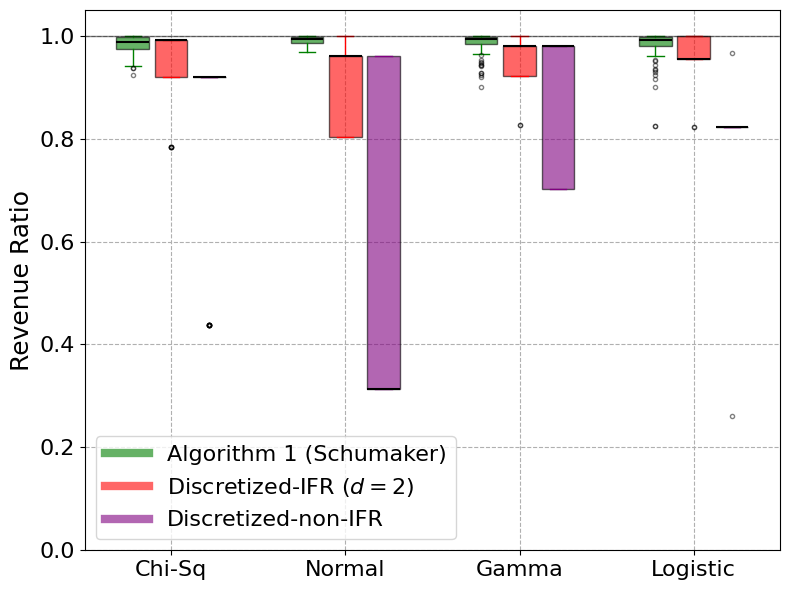

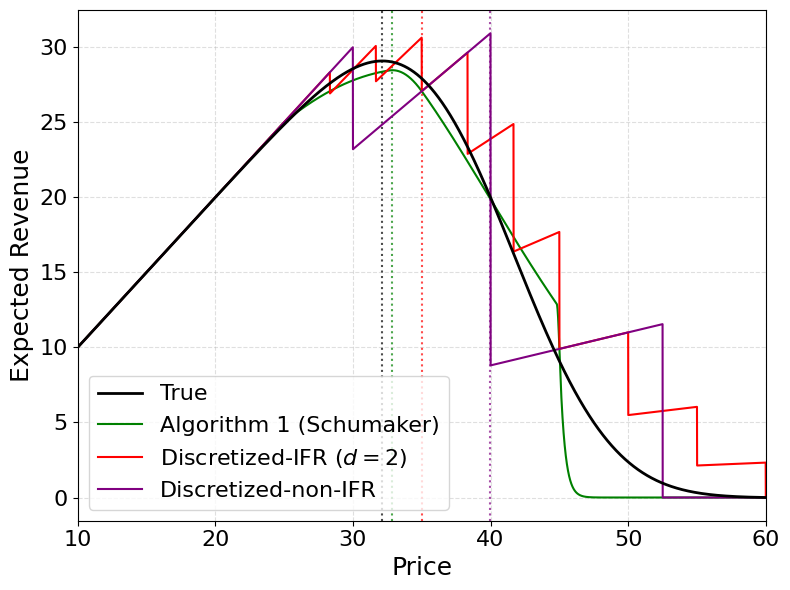

In [29]:
# ── Left: revenue ratio boxplots ────────────────────────────────────────────────
data = np.load('results/data/pricing_case_study.npz', allow_pickle=True)
dist_names_list  = data['dist_names'].tolist()
method_keys_list = data['method_keys'].tolist()
all_revenues     = data['all_revenues']

n_dists   = len(dist_names_list)
n_methods = len(method_keys_list)
width     = 0.22
offsets   = np.linspace(-(n_methods - 1) * width / 2, (n_methods - 1) * width / 2, n_methods)
x_pos     = np.arange(n_dists)
display_names = [DISTRIBUTIONS[k]['display_name'] for k in dist_names_list]

fig, ax_ratio = plt.subplots(figsize=(8, 6))
for j, m in enumerate(method_keys_list):
    ax_ratio.boxplot(
        [all_revenues[di, j, :] for di in range(n_dists)],
        positions=x_pos + offsets[j],
        widths=width * 0.85,
        patch_artist=True,
        boxprops=dict(facecolor=colors[m], alpha=0.6),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=colors[m]),
        capprops=dict(color=colors[m]),
        flierprops=dict(marker='o', color=colors[m], markersize=3, alpha=0.5),
        manage_ticks=False,
    )
    ax_ratio.plot([], [], color=colors[m], linewidth=6, alpha=0.6, label=method_labels[m])

ax_ratio.axhline(1.0, color='black', linewidth=1, alpha=0.5)
ax_ratio.set_xticks(x_pos)
ax_ratio.set_xticklabels(display_names)
ax_ratio.set_ylabel('Revenue Ratio')
ax_ratio.set_ylim([0, 1.05])
ax_ratio.grid(True, which='both', ls='--')
ax_ratio.legend(loc='lower left')
plt.tight_layout()
plt.savefig('results/plots/pricing_fig_revenue_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Right: single Normal illustration (seed 0) ──────────────────────────────────
np.random.seed(0)

ex_dist = DISTRIBUTIONS['Normal']['dist']
true_fine = ex_dist.cdf(x_fine)
true_p    = ex_dist.cdf(x_knots)
y_samples = np.random.binomial(n_trials, true_p)

true_rev     = x_fine * (1 - true_fine)
true_opt_idx = int(np.argmax(true_rev))

fig, ax_ex = plt.subplots(figsize=(8, 6))
ax_ex.plot(x_fine, true_rev, 'k-', linewidth=2, label='True', zorder=5)
ax_ex.axvline(x_fine[true_opt_idx], color='black', linestyle=':', linewidth=1.5, alpha=0.7)

try:
    fitted = fit_cdf(x_knots, n_trials, y_samples, l, u, 'schumaker')
    fn = sp.lambdify(x_sym, fitted, 'numpy')
    with np.errstate(invalid='ignore', over='ignore'):
        vals = np.clip(np.where(np.isfinite(np.array(fn(x_fine), dtype=float)),
                                np.array(fn(x_fine), dtype=float), 1.0), 0, 1)
    rev = x_fine * (1 - vals)
    ax_ex.plot(x_fine, rev, color='green', linewidth=1.5, label='Algorithm 1 (Schumaker)')
    ax_ex.axvline(x_fine[int(np.argmax(rev))], color='green', linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"algo1 failed: {e}")

try:
    x_nc, F_nc = fit_cdf_nonconvex(x_knots, n_trials, y_samples, l, u, d_ifr,
                                    ifr_constraint=True, verbose=False, return_type='values')
    F_nc_fine = F_nc[np.clip(np.searchsorted(x_nc, x_fine, side='right') - 1, 0, len(F_nc) - 1)]
    rev = x_fine * (1 - F_nc_fine)
    ax_ex.plot(x_fine, rev, color='red', linewidth=1.5, label=r'Discretized-IFR ($d=2$)')
    ax_ex.axvline(x_fine[int(np.argmax(rev))], color='red', linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"discretized_ifr failed: {e}")

try:
    x_ni, F_ni = fit_cdf_nonconvex(x_knots, n_trials, y_samples, l, u, 1,
                                    ifr_constraint=False, verbose=False, return_type='values')
    F_ni_fine = F_ni[np.clip(np.searchsorted(x_ni, x_fine, side='right') - 1, 0, len(F_ni) - 1)]
    rev = x_fine * (1 - F_ni_fine)
    ax_ex.plot(x_fine, rev, color='purple', linewidth=1.5, label='Discretized-non-IFR')
    ax_ex.axvline(x_fine[int(np.argmax(rev))], color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"discretized_non_ifr failed: {e}")

ax_ex.set_xlabel('Price')
ax_ex.set_ylabel('Expected Revenue')
ax_ex.set_xlim(l, u)
ax_ex.legend(loc='lower left')
ax_ex.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/plots/pricing_fig_revenue_example.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Case Study: Preventive Maintenance

This section reproduces and extends **Figure 8** from Chan, Chen, Fernandes, and Maaz (2025).

**Setting.** A component with random failure time $X \sim F_0$ on $[l, u]$ is replaced preventively at age $\kappa$ or upon failure, whichever comes first. Under the renewal-reward theorem, the expected cost per unit time is
$$C(\kappa;\, F_0) = \frac{c_p(1 - F_0(\kappa)) + c_f F_0(\kappa)}{\displaystyle\int_l^\kappa (1 - F_0(t))\,dt},$$
where $c_p < c_f$ are the preventive and corrective replacement costs. The optimal policy is $\kappa^* = \arg\min_\kappa C(\kappa;\, F_0)$.

**Estimate-then-optimize.** Each method fits $\hat{F}$ from binomial observations and sets $\hat{\kappa} = \arg\min_\kappa C(\kappa;\, \hat{F})$. Performance is measured by the **cost ratio**
$$\frac{C(\kappa^*;\, F_0)}{C(\hat{\kappa};\, F_0)} \in (0, 1],$$
where $1$ is optimal. A misspecified $\hat{F}$ can push $\hat{\kappa}$ far from $\kappa^*$, inflating the realized cost.

**Part 1 — Three methods compared across four distributions:**
- **Algorithm 1 (Schumaker):** distribution-free IFR estimator solved with CVXPY — no parametric assumption on $F_0$.
- **Discretized-IFR ($d=2$):** IFR enforced via bilinear inequalities on a refined grid with $d=2$ auxiliary points per interval; solved with Gurobi.
- **Discretized-non-IFR:** monotonicity constraint only, no IFR; solved with Gurobi.

**Part 2 — Two methods compared under correct specification and misspecification:**
- **Algorithm 1 (Schumaker):** as above.
- **Weibull Regression:** log-log linearization of empirical quantiles followed by OLS — assumes $F_0$ is Weibull.

## Part 1 — Multi-Distribution Comparison

Evaluates both methods across four IFR ground-truth distributions, all with support $[l, u] = [0, 50]$ months and **mode $\approx 8$–$10$ months**:

| Distribution | Parameters | Mode | IFR? |
|---|---|---|---|
| Chi-Sq | $df = 10$ | $8$ months | Yes (Gamma with shape $5 \geq 1$) |
| Normal | $\mu = 9,\; \sigma = 3$ | $9$ months | Yes (truncated Normal) |
| Gamma | $\alpha = 5,\; \theta = 2$ | $8$ months | Yes (shape $\geq 1$) |
| Logistic | $\mu = 9,\; s = 2$ | $9$ months | Yes (hazard $= F(x)$) |

**Design:** knots at $x_1 = 6$, $x_2 = 9$, $x_3 = 12$ months (roughly $0.7\times$, $1.0\times$, $1.3\times$ the mode); $n_i = 15$ trials per knot; 100 Monte Carlo replications; $c_p = 600$, $c_f = 1800$.

In [30]:
import warnings
from scipy.integrate import quad
from fitting import fit_weibull_cdf
from utils import minimize_fn
from scipy.stats import weibull_min as weibull_scipy

# ── Cost function C(kappa; F) = (c_p*(1-F(kappa)) + c_f*F(kappa)) / int_l^kappa (1-F(t))dt ──
def make_cost_fn(cdf_fn, c_p, c_f, l, x_knots=None):
    """cdf_fn must accept a scalar float and return a float in [0, 1]."""
    def cost(kappa):
        pts = [p for p in (x_knots or []) if l < p < kappa] or None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            integral, _ = quad(lambda t: 1.0 - cdf_fn(t), l + 1e-6, kappa,
                               points=pts, limit=600)
        if integral <= 0:
            return np.inf
        return (c_p * (1 - cdf_fn(kappa)) + c_f * cdf_fn(kappa)) / integral
    return cost


# ── Part 1 parameters ─────────────────────────────────────────────────────────────
l_r, u_r      = 0.0, 12.0
x_knots_r     = np.array([3.0, 6.0, 9.0])
n_per_knot_r  = 50
n_trials_r    = n_per_knot_r * np.ones(len(x_knots_r), dtype=int)
num_runs_r    = 100
c_p_r, c_f_r  = 300, 1200
x_fine_r      = np.linspace(l_r + 1e-4, u_r, 3000)
d_ifr_r       = 2

# Chi-Sq(10) = Gamma(5, scale=2): mode = df-2 = 8
# Normal(9, 3) truncated to [0,50]: mode = 9
# Gamma(5, scale=2): mode = (alpha-1)*scale = 8
# Logistic(9, 2): mode = loc = 9; hazard h(x) = F(x), strictly increasing
DIST_RELIABILITY = {
    'ChiSq':    {'label': 'Chi-Sq (df=10)',        'display_name': 'Chi-Sq',
                 'dist': TruncatedDist(chi2(10), l_r, u_r)},
    'Normal':   {'label': r'Normal ($\mu$=9, $\sigma$=3)', 'display_name': 'Normal',
                 'dist': truncnorm((l_r - 9.0) / 3.0, (u_r - 9.0) / 3.0, loc=9.0, scale=3.0)},
    'Gamma':    {'label': r'Gamma ($\alpha$=5, $\theta$=2)', 'display_name': 'Gamma',
                 'dist': TruncatedDist(gamma_dist(5, scale=2), l_r, u_r)},
    'Logistic': {'label': 'Logistic ($\mu$=9, s=2)', 'display_name': 'Logistic',
                 'dist': TruncatedDist(logistic(loc=9.0, scale=2.0), l_r, u_r)},
}

rel_method_keys = ['algo1', 'discretized_ifr', 'discretized_non_ifr']
rel_colors      = {'algo1': 'green', 'discretized_ifr': 'red', 'discretized_non_ifr': 'purple'}
rel_labels      = {
    'algo1':               'Algorithm 1 (Schumaker)',
    'discretized_ifr':     r'Discretized-IFR ($d=2$)',
    'discretized_non_ifr': 'Discretized-non-IFR',
}

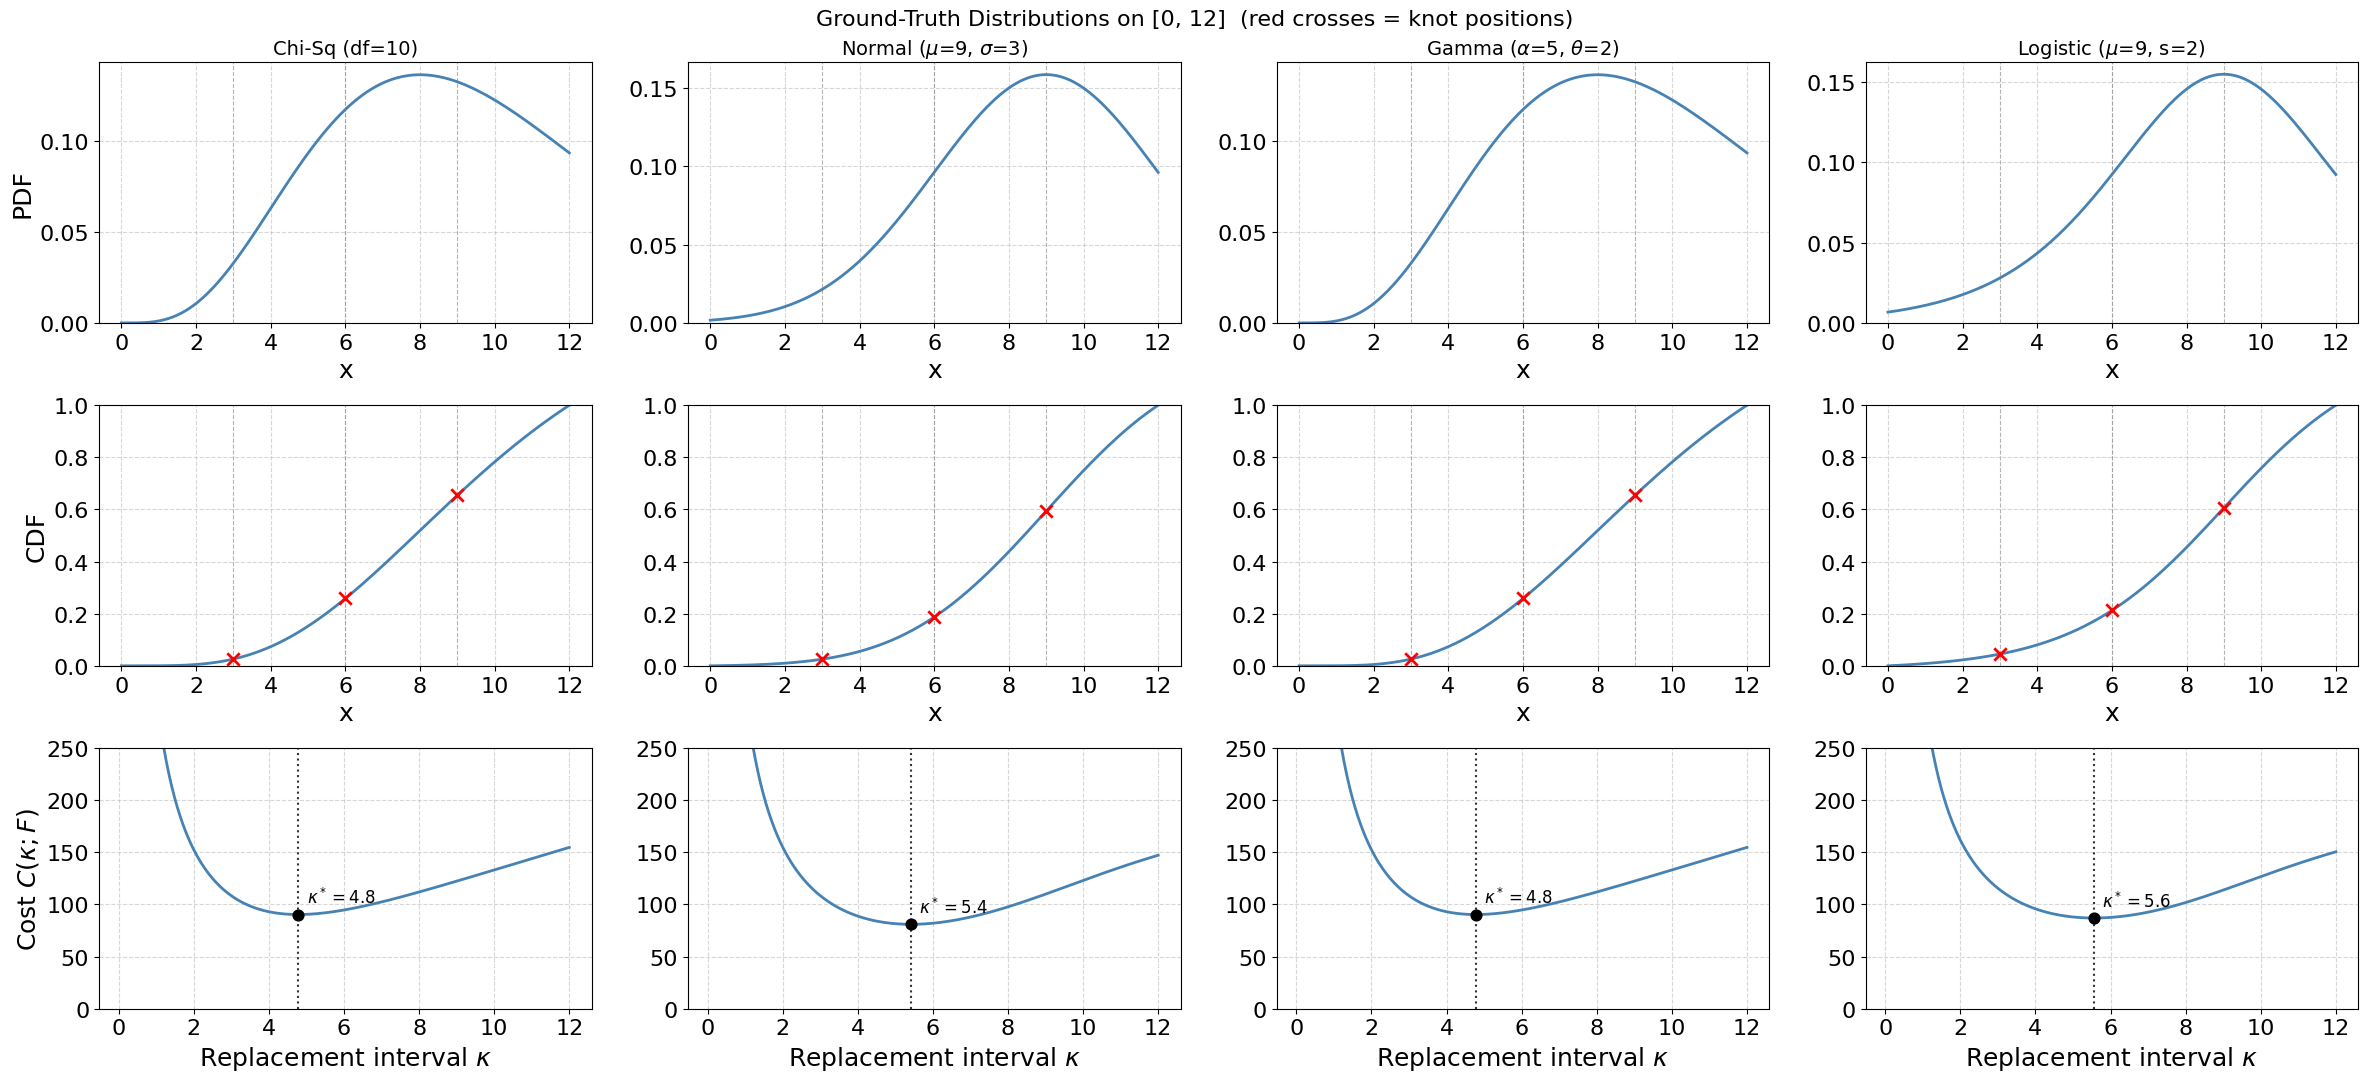

In [31]:
x_plot_r = np.linspace(l_r, u_r, 500)
x_cost_plot_r = x_plot_r[x_plot_r > l_r + 0.05]

fig, axes = plt.subplots(3, len(DIST_RELIABILITY), figsize=(6 * len(DIST_RELIABILITY), 11))

for j, (dist_key, dist_cfg) in enumerate(DIST_RELIABILITY.items()):
    dist        = dist_cfg['dist']
    pdf_vals    = dist.pdf(x_plot_r)
    cdf_vals    = dist.cdf(x_plot_r)
    true_cdf_fn = lambda t, _d=dist: float(np.clip(_d.cdf(np.array([t])), 0, 1).flat[0])
    cost_fn     = make_cost_fn(true_cdf_fn, c_p_r, c_f_r, l_r)
    cost_vals   = np.array([cost_fn(t) for t in x_cost_plot_r])

    kappa_star, _ = minimize_fn(cost_fn, (l_r + 0.01, u_r - 0.01))
    cost_star     = cost_fn(kappa_star)

    ax_pdf  = axes[0, j]
    ax_cdf  = axes[1, j]
    ax_cost = axes[2, j]

    ax_pdf.plot(x_plot_r, pdf_vals, color='steelblue', linewidth=2)
    for xk in x_knots_r:
        ax_pdf.axvline(xk, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax_pdf.set_title(dist_cfg['label'], fontsize=14)
    ax_pdf.set_xlabel('x')
    ax_pdf.set_ylim(bottom=0)
    ax_pdf.grid(True, ls='--', alpha=0.5)

    ax_cdf.plot(x_plot_r, cdf_vals, color='steelblue', linewidth=2)
    for xk in x_knots_r:
        ax_cdf.axvline(xk, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax_cdf.scatter([xk], [dist.cdf(np.array([xk]))],
                       color='red', zorder=5, s=80, marker='x', linewidths=2)
    ax_cdf.set_xlabel('x')
    ax_cdf.set_ylim(0, 1)
    ax_cdf.grid(True, ls='--', alpha=0.5)

    ax_cost.plot(x_cost_plot_r, cost_vals, color='steelblue', linewidth=2)
    ax_cost.axvline(kappa_star, color='black', linestyle=':', linewidth=1.5, alpha=0.8)
    ax_cost.scatter([kappa_star], [cost_star], color='black', zorder=5, s=60)
    ax_cost.annotate(fr'$\kappa^*={kappa_star:.1f}$', xy=(kappa_star, cost_star),
                     xytext=(6, 8), textcoords='offset points', fontsize=12)
    ax_cost.set_xlabel(r'Replacement interval $\kappa$')
    ax_cost.set_ylim(bottom=0, top = 250)
    ax_cost.grid(True, ls='--', alpha=0.5)

axes[0, 0].set_ylabel('PDF', fontsize=18)
axes[1, 0].set_ylabel('CDF', fontsize=18)
axes[2, 0].set_ylabel(r'Cost $C(\kappa;F)$', fontsize=18)

plt.suptitle(f'Ground-Truth Distributions on [{l_r:.0f}, {u_r:.0f}]  (red crosses = knot positions)', fontsize=16)
plt.tight_layout()
plt.savefig('results/plots/reliability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
np.random.seed(1)

mask_r = x_fine_r <= x_knots_r[-1]

rel_dist_names    = list(DIST_RELIABILITY.keys())
n_rd = len(rel_dist_names)
n_rm = len(rel_method_keys)
all_errors_r      = np.full((n_rd, n_rm, num_runs_r), np.nan)
all_errors_r_knot = np.full((n_rd, n_rm, num_runs_r), np.nan)
all_costs_r       = np.full((n_rd, n_rm, num_runs_r), np.nan)

for di, (dist_name, dist_cfg) in enumerate(DIST_RELIABILITY.items()):
    dist           = dist_cfg['dist']
    true_cdf_fn    = lambda t, _d=dist: float(np.clip(_d.cdf(np.array([t])), 0, 1).flat[0])
    true_p         = dist.cdf(x_knots_r)
    true_fine      = dist.cdf(x_fine_r)
    true_fine_knot = true_fine[mask_r]

    true_cost_fn   = make_cost_fn(true_cdf_fn, c_p_r, c_f_r, l_r)
    kappa_star, _  = minimize_fn(true_cost_fn, (l_r + 0.01, u_r - 0.01))
    cost_star      = true_cost_fn(kappa_star)
    print(f"{dist_name}: kappa* = {kappa_star:.2f} months, C(kappa*) = {cost_star:.4f}")

    for run in tqdm(range(num_runs_r), desc=dist_name, leave=False):
        y_samples = np.random.binomial(n_trials_r, true_p)

        # ── Algorithm 1 (Schumaker) ──────────────────────────────────────────────
        try:
            fitted_sch = fit_cdf(x_knots_r, n_trials_r, y_samples, l_r, u_r, 'schumaker')
            fn_raw     = sp.lambdify(x_sym, fitted_sch, 'numpy')
            def fn_sch(t, _f=fn_raw):
                with np.errstate(invalid='ignore', over='ignore'):
                    return float(np.clip(np.asarray(_f(t), dtype=float).flat[0], 0, 1))
            vals_sch                       = np.array([fn_sch(t) for t in x_fine_r])
            all_errors_r[di, 0, run]      = float(np.max(np.abs(vals_sch - true_fine)))
            all_errors_r_knot[di, 0, run] = float(np.max(np.abs(vals_sch[mask_r] - true_fine_knot)))
            cost_fn_sch   = make_cost_fn(fn_sch, c_p_r, c_f_r, l_r, x_knots=list(x_knots_r))
            kappa_sch, _  = minimize_fn(cost_fn_sch, (l_r + 0.01, u_r - 0.01))
            all_costs_r[di, 0, run] = cost_star / true_cost_fn(kappa_sch)
        except Exception as e:
            print(f"  [{dist_name}, run {run}] algo1 failed: {e}")

        # ── Discretized-IFR (Gurobi, d=d_ifr_r) ─────────────────────────────────
        try:
            x_nc, F_nc = fit_cdf_nonconvex(
                x_knots_r, n_trials_r, y_samples, l_r, u_r, d_ifr_r,
                ifr_constraint=True, verbose=False, return_type='values',
            )
            def fn_disc_ifr(t, _x=x_nc, _F=F_nc):
                idx = int(np.clip(np.searchsorted(_x, t, side='right') - 1, 0, len(_F) - 1))
                return float(_F[idx])
            all_errors_r[di, 1, run]      = _l_inf_step(x_nc, F_nc, dist.cdf)
            all_errors_r_knot[di, 1, run] = _l_inf_step(x_nc, F_nc, dist.cdf, x_max=x_knots_r[-1])
            cost_fn_disc  = make_cost_fn(fn_disc_ifr, c_p_r, c_f_r, l_r)
            kappa_disc, _ = minimize_fn(cost_fn_disc, (l_r + 0.01, u_r - 0.01))
            all_costs_r[di, 1, run] = cost_star / true_cost_fn(kappa_disc)
        except Exception as e:
            print(f"  [{dist_name}, run {run}] discretized_ifr failed: {e}")

        # ── Discretized-non-IFR (Gurobi, monotonicity only) ─────────────────────
        try:
            x_ni, F_ni = fit_cdf_nonconvex(
                x_knots_r, n_trials_r, y_samples, l_r, u_r, 0,
                ifr_constraint=False, verbose=False, return_type='values',
            )
            def fn_disc_nifr(t, _x=x_ni, _F=F_ni):
                idx = int(np.clip(np.searchsorted(_x, t, side='right') - 1, 0, len(_F) - 1))
                return float(_F[idx])
            all_errors_r[di, 2, run]      = _l_inf_step(x_ni, F_ni, dist.cdf)
            all_errors_r_knot[di, 2, run] = _l_inf_step(x_ni, F_ni, dist.cdf, x_max=x_knots_r[-1])
            cost_fn_nifr   = make_cost_fn(fn_disc_nifr, c_p_r, c_f_r, l_r)
            kappa_nifr, _  = minimize_fn(cost_fn_nifr, (l_r + 0.01, u_r - 0.01))
            all_costs_r[di, 2, run] = cost_star / true_cost_fn(kappa_nifr)
        except Exception as e:
            print(f"  [{dist_name}, run {run}] discretized_non_ifr failed: {e}")

np.savez('results/data/reliability_case_study_multi_dist.npz',
    dist_names=np.array(rel_dist_names),
    all_errors=all_errors_r,
    all_errors_knot=all_errors_r_knot,
    all_costs=all_costs_r,
)
print('Saved numerical_results/reliability_case_study_multi_dist.npz')

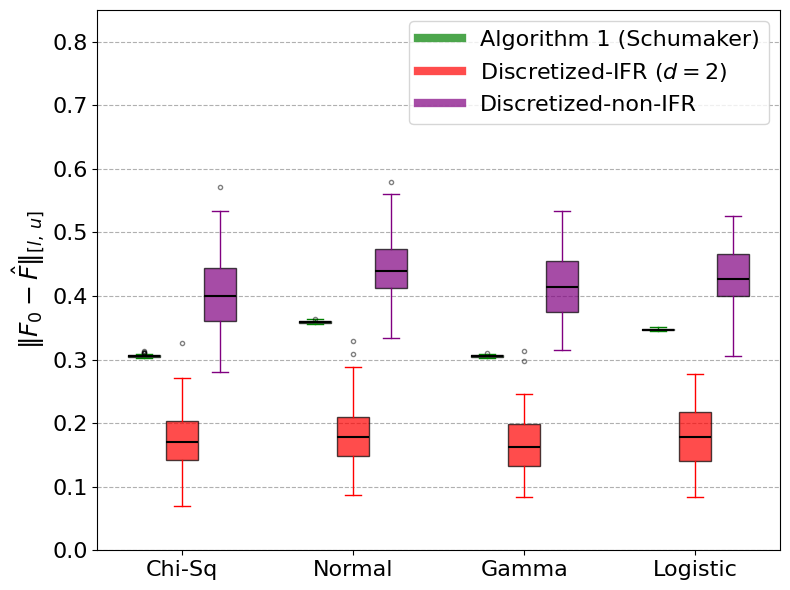

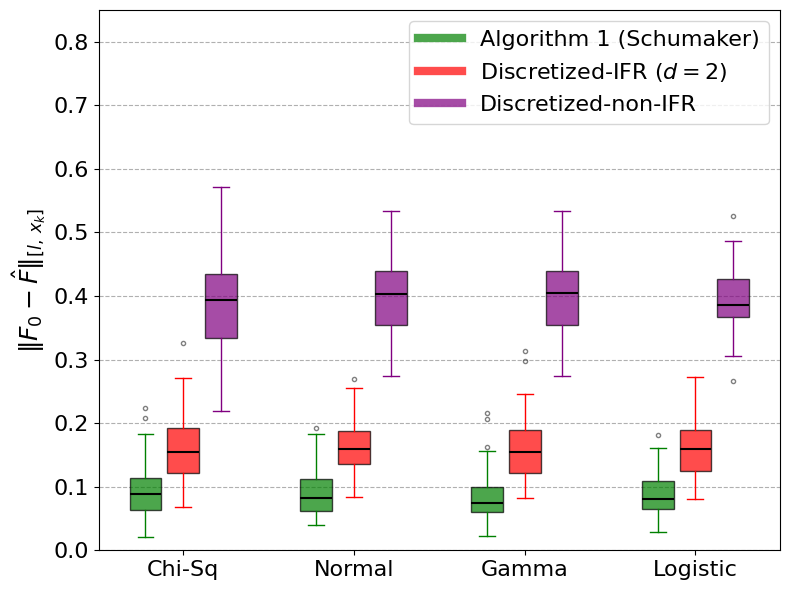

In [32]:
data_r = np.load('results/data/reliability_case_study_multi_dist.npz', allow_pickle=True)
rel_dist_names    = data_r['dist_names'].tolist()
all_errors_r      = data_r['all_errors']
all_errors_r_knot = data_r['all_errors_knot']

n_rd  = len(rel_dist_names)
n_rm  = len(rel_method_keys)
width = 0.22
offsets_r       = np.linspace(-(n_rm - 1) * width / 2, (n_rm - 1) * width / 2, n_rm)
x_pos_r         = np.arange(n_rd)
display_names_r = [DIST_RELIABILITY[k]['display_name'] for k in rel_dist_names]

def _rel_boxplots(ax, arr_3d):
    for j, m in enumerate(rel_method_keys):
        ax.boxplot(
            [arr_3d[di, j, :] for di in range(n_rd)],
            positions=x_pos_r + offsets_r[j],
            widths=width * 0.85,
            patch_artist=True,
            boxprops=dict(facecolor=rel_colors[m], alpha=0.7),
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color=rel_colors[m]),
            capprops=dict(color=rel_colors[m]),
            flierprops=dict(marker='o', color=rel_colors[m], markersize=3, alpha=0.5),
            manage_ticks=False,
        )
        ax.plot([], [], color=rel_colors[m], linewidth=6, alpha=0.7, label=rel_labels[m])

# --- Full L-inf error ---
fig, ax_full = plt.subplots(figsize=(8, 6))
_rel_boxplots(ax_full, all_errors_r)
ax_full.set_xticks(x_pos_r)
ax_full.set_xticklabels(display_names_r)
ax_full.set_ylabel(r'$\|F_0 - \hat{F}\|_{[l,\,u]}$')
ax_full.set_ylim(0, 0.85)
ax_full.grid(True, axis='y', ls='--')
ax_full.legend(loc='upper right')
plt.tight_layout()
plt.savefig('results/plots/reliability_fig_errors_full.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Restricted L-inf error on observed region [l, x_k] ---
fig, ax_knot = plt.subplots(figsize=(8, 6))
_rel_boxplots(ax_knot, all_errors_r_knot)
ax_knot.set_xticks(x_pos_r)
ax_knot.set_xticklabels(display_names_r)
ax_knot.set_ylabel(r'$\|F_0 - \hat{F}\|_{[l,\,x_k]}$')
ax_knot.set_ylim(0, 0.85)
ax_knot.grid(True, axis='y', ls='--')
ax_knot.legend(loc='upper right')
plt.tight_layout()
plt.savefig('results/plots/reliability_fig_errors_knot.png', dpi=150, bbox_inches='tight')
plt.show()

### Cost Performance and Single-Run Illustration

- **Left:** cost ratio $C(\kappa^*;\,F_0) / C(\hat\kappa;\,F_0)$ across all Monte Carlo runs and distributions. Values close to 1 indicate the estimated policy nearly matches the oracle.
- **Right:** a single replication (seed 0) for the Normal distribution showing the cost curve $C(\kappa;\,\hat{F})$ for each method. Dotted vertical lines mark each $\hat\kappa$; the black dotted line is the oracle $\kappa^*$. A poorly shaped cost curve from a non-IFR estimate shifts $\hat\kappa$ away from $\kappa^*$, inflating the realized cost.

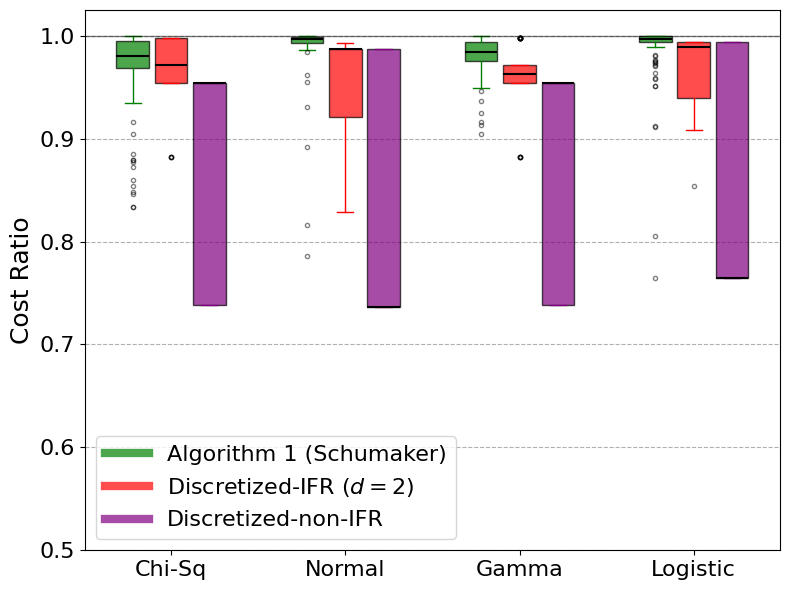

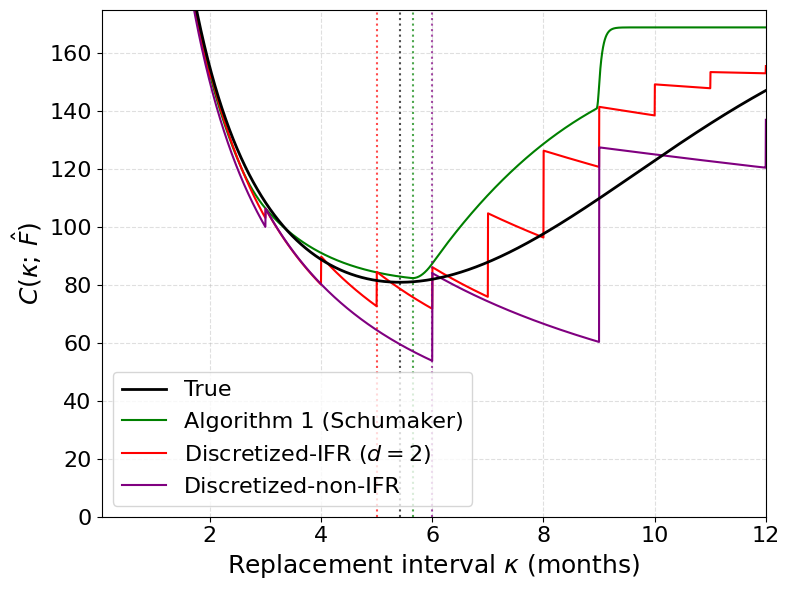

In [33]:
data_r = np.load('results/data/reliability_case_study_multi_dist.npz', allow_pickle=True)
rel_dist_names = data_r['dist_names'].tolist()
all_costs_r    = data_r['all_costs']

n_rd  = len(rel_dist_names)
n_rm  = len(rel_method_keys)
width = 0.22
offsets_r       = np.linspace(-(n_rm - 1) * width / 2, (n_rm - 1) * width / 2, n_rm)
x_pos_r         = np.arange(n_rd)
display_names_r = [DIST_RELIABILITY[k]['display_name'] for k in rel_dist_names]

# --- Cost ratio boxplots ---
fig, ax_cost = plt.subplots(figsize=(8, 6))
for j, m in enumerate(rel_method_keys):
    ax_cost.boxplot(
        [all_costs_r[di, j, :] for di in range(n_rd)],
        positions=x_pos_r + offsets_r[j],
        widths=width * 0.85,
        patch_artist=True,
        boxprops=dict(facecolor=rel_colors[m], alpha=0.7),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=rel_colors[m]),
        capprops=dict(color=rel_colors[m]),
        flierprops=dict(marker='o', color=rel_colors[m], markersize=3, alpha=0.5),
        manage_ticks=False,
    )
    ax_cost.plot([], [], color=rel_colors[m], linewidth=6, alpha=0.7, label=rel_labels[m])

ax_cost.axhline(1.0, color='black', linewidth=1, alpha=0.5)
ax_cost.set_xticks(x_pos_r)
ax_cost.set_xticklabels(display_names_r)
ax_cost.set_ylabel('Cost Ratio')
ax_cost.set_ylim(0.5, 1.025)
ax_cost.grid(True, axis='y', ls='--')
ax_cost.legend(loc='lower left')
plt.tight_layout()
plt.savefig('results/plots/reliability_fig_cost_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Single Normal run cost curve (seed 1) ---
np.random.seed(1)
ex_dist      = DIST_RELIABILITY['Normal']['dist']
true_p_ex    = ex_dist.cdf(x_knots_r)
y_samples_ex = np.random.binomial(n_trials_r, true_p_ex)

true_cdf_fn_ex   = lambda t, _d=ex_dist: float(np.clip(_d.cdf(np.array([t])), 0, 1).flat[0])
true_cost_fn_ex  = make_cost_fn(true_cdf_fn_ex, c_p_r, c_f_r, l_r)
kappa_star_ex, _ = minimize_fn(true_cost_fn_ex, (l_r + 0.01, u_r - 0.01))

x_cost_plot = x_fine_r[x_fine_r > l_r + 0.05]
true_cv = np.array([true_cost_fn_ex(t) for t in x_cost_plot])

fig, ax_ex = plt.subplots(figsize=(8, 6))
ax_ex.plot(x_cost_plot, true_cv, 'k-', linewidth=2, label='True', zorder=5)
ax_ex.axvline(kappa_star_ex, color='black', linestyle=':', linewidth=1.5, alpha=0.7)

try:
    fitted   = fit_cdf(x_knots_r, n_trials_r, y_samples_ex, l_r, u_r, 'schumaker')
    fn_raw   = sp.lambdify(x_sym, fitted, 'numpy')
    def fn_s(t, _f=fn_raw):
        with np.errstate(invalid='ignore', over='ignore'):
            return float(np.clip(np.asarray(_f(t), dtype=float).flat[0], 0, 1))
    cost_fn  = make_cost_fn(fn_s, c_p_r, c_f_r, l_r, x_knots=list(x_knots_r))
    cv       = np.array([cost_fn(t) for t in x_cost_plot])
    kappa_hat, _ = minimize_fn(cost_fn, (l_r + 0.01, u_r - 0.01))
    m = np.isfinite(cv)
    ax_ex.plot(x_cost_plot[m], cv[m], color=rel_colors['algo1'], linewidth=1.5, label=rel_labels['algo1'])
    ax_ex.axvline(kappa_hat, color=rel_colors['algo1'], linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"algo1 failed: {e}")

try:
    x_nc, F_nc = fit_cdf_nonconvex(x_knots_r, n_trials_r, y_samples_ex, l_r, u_r, d_ifr_r,
                                    ifr_constraint=True, verbose=False, return_type='values')
    def fn_d(t, _x=x_nc, _F=F_nc):
        idx = int(np.clip(np.searchsorted(_x, t, side='right') - 1, 0, len(_F) - 1))
        return float(_F[idx])
    cost_fn  = make_cost_fn(fn_d, c_p_r, c_f_r, l_r)
    cv       = np.array([cost_fn(t) for t in x_cost_plot])
    kappa_hat, _ = minimize_fn(cost_fn, (l_r + 0.01, u_r - 0.01))
    m = np.isfinite(cv)
    ax_ex.plot(x_cost_plot[m], cv[m], color=rel_colors['discretized_ifr'], linewidth=1.5, label=rel_labels['discretized_ifr'])
    ax_ex.axvline(kappa_hat, color=rel_colors['discretized_ifr'], linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"discretized_ifr failed: {e}")

try:
    x_ni, F_ni = fit_cdf_nonconvex(x_knots_r, n_trials_r, y_samples_ex, l_r, u_r, 0,
                                    ifr_constraint=False, verbose=False, return_type='values')
    def fn_n(t, _x=x_ni, _F=F_ni):
        idx = int(np.clip(np.searchsorted(_x, t, side='right') - 1, 0, len(_F) - 1))
        return float(_F[idx])
    cost_fn  = make_cost_fn(fn_n, c_p_r, c_f_r, l_r)
    cv       = np.array([cost_fn(t) for t in x_cost_plot])
    kappa_hat, _ = minimize_fn(cost_fn, (l_r + 0.01, u_r - 0.01))
    m = np.isfinite(cv)
    ax_ex.plot(x_cost_plot[m], cv[m], color=rel_colors['discretized_non_ifr'], linewidth=1.5, label=rel_labels['discretized_non_ifr'])
    ax_ex.axvline(kappa_hat, color=rel_colors['discretized_non_ifr'], linestyle=':', linewidth=1.5, alpha=0.7)
except Exception as e:
    print(f"discretized_non_ifr failed: {e}")

ax_ex.set_xlabel(r'Replacement interval $\kappa$ (months)')
ax_ex.set_ylabel(r'$C(\kappa;\,\hat{F})$')
ax_ex.set_xlim(l_r + 0.05, u_r)
ax_ex.set_ylim(bottom=0, top=175)
ax_ex.legend(loc='lower left')
ax_ex.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/plots/reliability_fig_cost_example.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2 — Weibull: Correct Specification vs. Misspecification

Reproduces the structure of **Figure 8** from the paper. Both experiments use support $[0, 100]$ months, knots at $x_1 = 24$, $x_2 = 30$, $x_3 = 36$, and sweep $n_i \in \{10, 15, 20\}$ trials per knot. Costs: $c_p = 600$, $c_f = 1800$.

**Experiment 1 (correct spec):** True $F_0 \sim \text{Weibull}(\text{shape}=5,\, \text{scale}=30)$ truncated to $[0,100]$, mode $\approx 28.7$ months, mean $\approx 27.5$ months. Weibull regression uses the correct parametric form, so the log-log linearization is exact in expectation.

**Experiment 2 (misspecification):** True $F_0 \sim \text{Gamma}(\alpha=8,\, \theta=6)$ truncated to $[0,100]$, mode $= 42$ months, mean $= 48$ months. Weibull regression assumes the wrong family; Algorithm 1 is distribution-free and requires no parametric assumption.

The cost ratio $C(\kappa^*; F_0) / C(\hat\kappa; F_0) \leq 1$ with $1$ being optimal. Under misspecification, Weibull regression can produce a poor $\hat\kappa$ even when $n_i$ is large, while Algorithm 1 is robustly better.

In [ ]:
np.random.seed(0)

# ── Part 2 parameters ─────────────────────────────────────────────────────────────
l_w, u_w         = 0.0, 100.0
x_knots_w        = np.array([24.0, 30.0, 36.0])
n_per_knot_list  = [10, 15, 20]
num_runs_w       = 100
c_p_w, c_f_w     = 600, 1800
x_fine_w         = np.linspace(l_w + 1e-4, u_w, 3000)

# Experiment 1: Weibull(shape=5, scale=30) truncated to [0,100] — correct spec
#   mode = 30*(4/5)^(1/5) ≈ 28.7 months; F(100) ≈ 1 so truncation is negligible
# Experiment 2: Gamma(alpha=8, scale=6) truncated to [0,100] — misspecification
#   mode = (8-1)*6 = 42 months; mean = 48; F(100) ≈ 0.9987
EXP_DISTS = {
    'Weibull': TruncatedDist(weibull_scipy(5, scale=30.0), l_w, u_w),
    'Gamma':   TruncatedDist(gamma_dist(8, scale=6.0),    l_w, u_w),
}

results_exp = {name: {} for name in EXP_DISTS}

for exp_name, exp_dist in EXP_DISTS.items():
    true_cdf_fn_w = lambda t, _d=exp_dist: float(np.clip(_d.cdf(np.array([t])), 0, 1).flat[0])
    true_p_w      = exp_dist.cdf(x_knots_w)
    true_fine_w   = exp_dist.cdf(x_fine_w)

    true_cost_fn_w  = make_cost_fn(true_cdf_fn_w, c_p_w, c_f_w, l_w)
    kappa_star_w, _ = minimize_fn(true_cost_fn_w, (l_w + 0.01, u_w - 0.01))
    cost_star_w     = true_cost_fn_w(kappa_star_w)
    print(f"{exp_name}: kappa* = {kappa_star_w:.2f} months, C(kappa*) = {cost_star_w:.4f}")

    for n in n_per_knot_list:
        n_trials_w = n * np.ones(len(x_knots_w), dtype=int)
        ratios_sch, ratios_weib = [], []
        errors_sch, errors_weib = [], []

        for _ in tqdm(range(num_runs_w), desc=f"{exp_name} n={n}", leave=False):
            y_samples = np.random.binomial(n_trials_w, true_p_w)

            # Algorithm 1 (Schumaker)
            try:
                fitted_sch   = fit_cdf(x_knots_w, n_trials_w, y_samples, l_w, u_w, 'schumaker')
                fn_raw_sch   = sp.lambdify(x_sym, fitted_sch, 'numpy')
                def fn_sch(t, _f=fn_raw_sch):
                    with np.errstate(invalid='ignore', over='ignore'):
                        return float(np.clip(np.asarray(_f(t), dtype=float).flat[0], 0, 1))
                vals_sch = np.array([fn_sch(t) for t in x_fine_w])
                errors_sch.append(float(np.max(np.abs(vals_sch - true_fine_w))))
                cost_fn_sch  = make_cost_fn(fn_sch, c_p_w, c_f_w, l_w, x_knots=list(x_knots_w))
                kappa_sch, _ = minimize_fn(cost_fn_sch, (l_w + 0.01, u_w - 0.01))
                ratios_sch.append(cost_star_w / true_cost_fn_w(kappa_sch))
            except Exception as e:
                errors_sch.append(np.nan)
                ratios_sch.append(np.nan)

            # Weibull Regression
            try:
                fitted_weib   = fit_weibull_cdf(x_knots_w, n_trials_w, y_samples, l_w, u_w, x_sym)
                fn_raw_weib   = sp.lambdify(x_sym, fitted_weib, 'numpy')
                def fn_weib(t, _f=fn_raw_weib):
                    with np.errstate(invalid='ignore', over='ignore'):
                        return float(np.clip(np.asarray(_f(t), dtype=float).flat[0], 0, 1))
                vals_weib = np.array([fn_weib(t) for t in x_fine_w])
                errors_weib.append(float(np.max(np.abs(vals_weib - true_fine_w))))
                cost_fn_weib  = make_cost_fn(fn_weib, c_p_w, c_f_w, l_w)
                kappa_weib, _ = minimize_fn(cost_fn_weib, (l_w + 0.01, u_w - 0.01))
                ratios_weib.append(cost_star_w / true_cost_fn_w(kappa_weib))
            except Exception as e:
                errors_weib.append(np.nan)
                ratios_weib.append(np.nan)

        results_exp[exp_name][n] = {
            'algo1':          np.array(ratios_sch),
            'weibull':        np.array(ratios_weib),
            'errors_algo1':   np.array(errors_sch),
            'errors_weibull': np.array(errors_weib),
        }

np.savez('results/data/reliability_case_study_weibull.npz',
    exp_names=np.array(list(EXP_DISTS.keys())),
    n_values=np.array(n_per_knot_list),
    **{f'{en}_{n}_{k}': results_exp[en][n][k]
       for en in EXP_DISTS for n in n_per_knot_list
       for k in ['algo1', 'weibull', 'errors_algo1', 'errors_weibull']},
)
print('Saved numerical_results/reliability_case_study_weibull.npz')

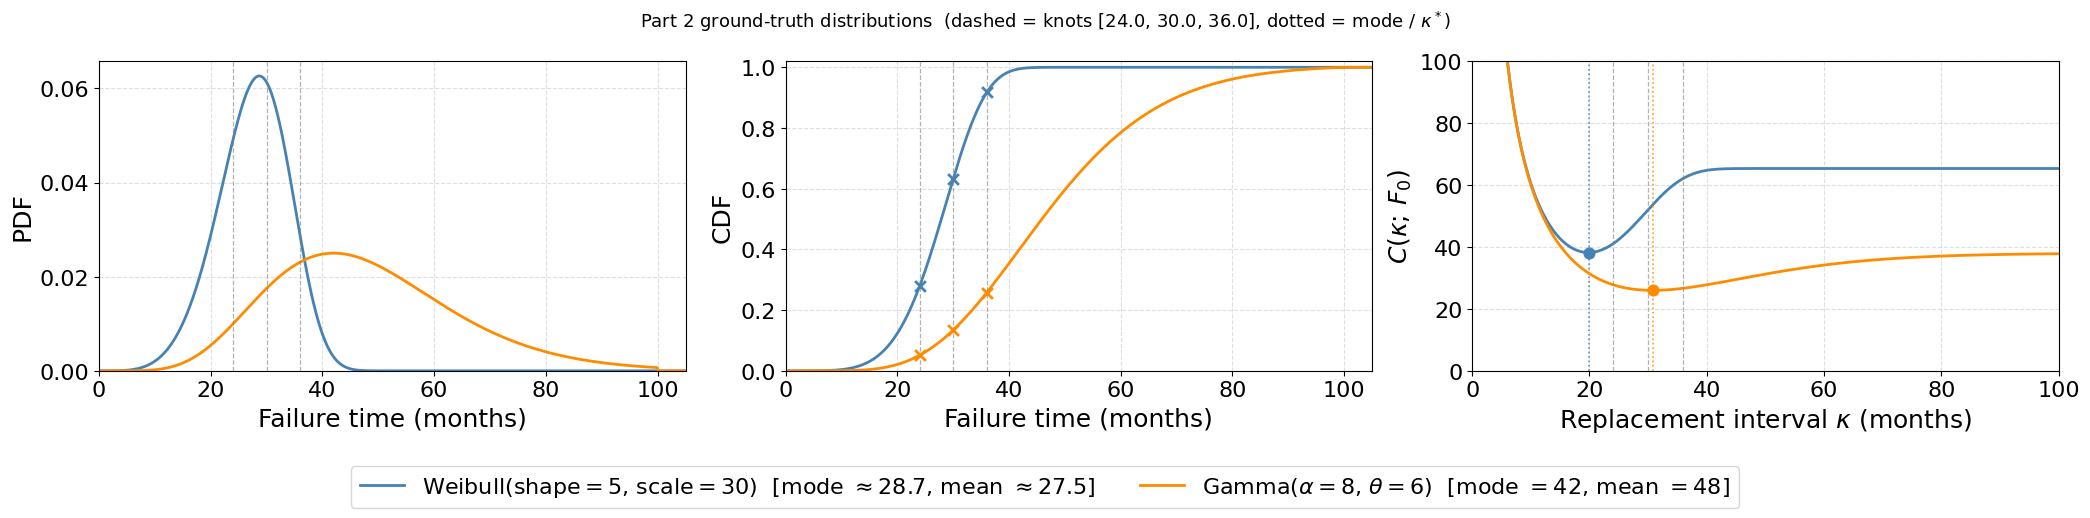

In [34]:
l_w, u_w         = 0.0, 100.0
c_p_w, c_f_w     = 600, 1800
x_plot_w = np.linspace(0.0, 105.0, 1000)
x_cost_w = np.linspace(0.5, u_w, 500)
x_knots_w        = np.array([24.0, 30.0, 36.0])
n_per_knot_list  = [10, 15, 20]
num_runs_w       = 100

EXP_DISTS = {
    'Weibull': TruncatedDist(weibull_scipy(5, scale=30.0), l_w, u_w),
    'Gamma':   TruncatedDist(gamma_dist(8, scale=6.0),    l_w, u_w),
}

results_exp = {name: {} for name in EXP_DISTS}

dist_cfg = {
    'Weibull': {
        'dist':  TruncatedDist(weibull_scipy(5, scale=30.0), l_w, u_w),
        'label': r'Weibull(shape$=5$, scale$=30$)  [mode $\approx 28.7$, mean $\approx 27.5$]',
        'color': 'steelblue'
    },
    'Gamma': {
        'dist':  TruncatedDist(gamma_dist(8, scale=6.0), l_w, u_w),
        'label': r'Gamma($\alpha=8$, $\theta=6$)  [mode $= 42$, mean $= 48$]',
        'color': 'darkorange'
    },
}

fig, (ax_pdf, ax_cdf, ax_cost) = plt.subplots(1, 3, figsize=(21, 5))

for name, cfg in dist_cfg.items():
    d     = cfg['dist']
    color = cfg['color']
    label = cfg['label']

    ax_pdf.plot(x_plot_w, d.pdf(x_plot_w), color=color, linewidth=2, label=label)
    ax_cdf.plot(x_plot_w, d.cdf(x_plot_w), color=color, linewidth=2, label=label)

    # Cost curve C(kappa; F_0) using the true (truncated) CDF
    cdf_scalar = lambda t, _d=d: float(np.clip(_d.cdf(np.array([t])), 0, 1).flat[0])
    cost_fn_true = make_cost_fn(cdf_scalar, c_p_w, c_f_w, l_w)
    kappa_star_plot, _ = minimize_fn(cost_fn_true, (l_w + 0.01, u_w - 0.01))
    cv = np.array([cost_fn_true(k) for k in x_cost_w])
    m  = np.isfinite(cv)
    ax_cost.plot(x_cost_w[m], cv[m], color=color, linewidth=2, label=label)
    ax_cost.axvline(kappa_star_plot, color=color, linewidth=1.2, linestyle=':', alpha=0.85)
    ax_cost.scatter([kappa_star_plot], [cost_fn_true(kappa_star_plot)],
                    color=color, zorder=5, s=60)

# Mark knots on all panels
for ax in (ax_pdf, ax_cdf, ax_cost):
    for xk in x_knots_w:
        ax.axvline(xk, color='gray', linewidth=0.9, linestyle='--', alpha=0.6)
    ax.grid(True, ls='--', alpha=0.4)

ax_pdf.set_xlabel('Failure time (months)')
ax_pdf.set_ylabel('PDF')
ax_pdf.set_ylim(bottom=0)
ax_pdf.set_xlim(0, 105)

ax_cdf.set_xlabel('Failure time (months)')
ax_cdf.set_ylabel('CDF')
ax_cdf.set_ylim(0, 1.02)
ax_cdf.set_xlim(0, 105)
for name, cfg in dist_cfg.items():
    for xk in x_knots_w:
        ax_cdf.scatter([xk], [cfg['dist'].cdf(xk)], color=cfg['color'],
                       zorder=5, s=60, marker='x', linewidths=2)

ax_cost.set_xlabel(r'Replacement interval $\kappa$ (months)')
ax_cost.set_ylabel(r'$C(\kappa;\, F_0)$')
ax_cost.set_xlim(0, u_w)
ax_cost.set_ylim(bottom=0, top = 100)

handles, labels_leg = ax_pdf.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.suptitle(
    f'Part 2 ground-truth distributions  (dashed = knots {x_knots_w.tolist()}, dotted = mode / $\\kappa^*$)',
    fontsize=13,
)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('results/plots/reliability_part2_dists.png', dpi=150, bbox_inches='tight')
plt.show()

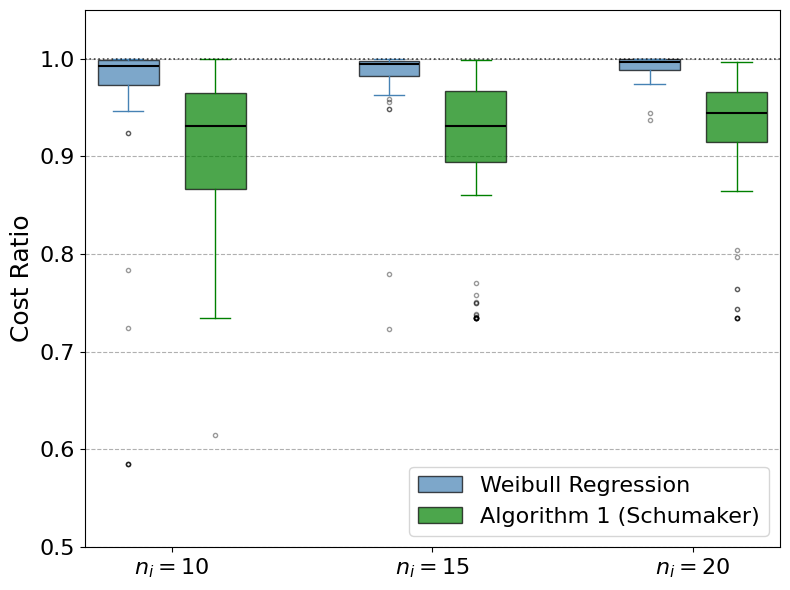

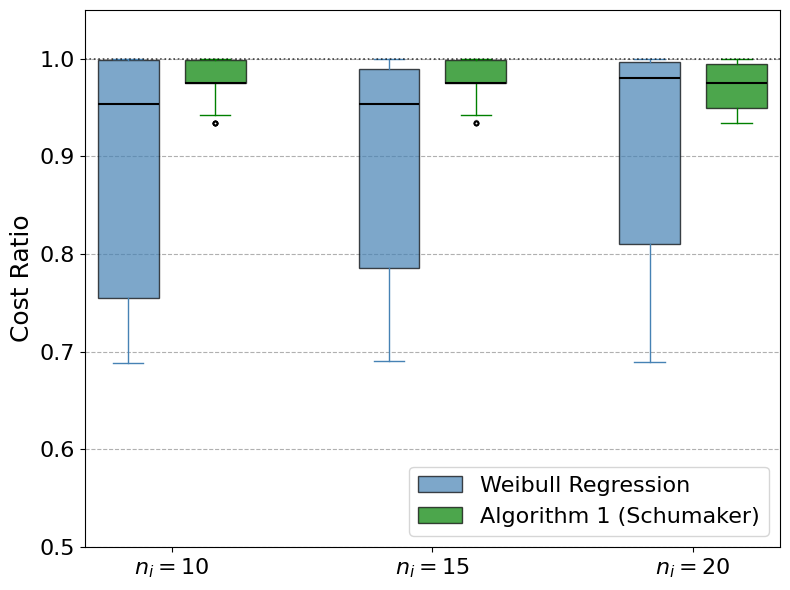

In [35]:
data_w  = np.load('results/data/reliability_case_study_weibull.npz', allow_pickle=True)
exp_names_w  = data_w['exp_names'].tolist()
n_values_w   = data_w['n_values'].tolist()

for exp_name in exp_names_w:
    fig, ax = plt.subplots(figsize=(8, 6))
    n_nv  = len(n_values_w)
    pos_w = [3 * i + 1 for i in range(n_nv)]
    pos_s = [3 * i + 2 for i in range(n_nv)]

    bp_weib = ax.boxplot(
        [data_w[f'{exp_name}_{n}_weibull'] for n in n_values_w],
        positions=pos_w, widths=0.7, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='steelblue'), capprops=dict(color='steelblue'),
        flierprops=dict(marker='o', markersize=3, color='steelblue', alpha=0.4),
    )
    bp_algo = ax.boxplot(
        [data_w[f'{exp_name}_{n}_algo1'] for n in n_values_w],
        positions=pos_s, widths=0.7, patch_artist=True,
        boxprops=dict(facecolor='green', alpha=0.7),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='green'), capprops=dict(color='green'),
        flierprops=dict(marker='o', markersize=3, color='green', alpha=0.4),
    )
    ax.axhline(1.0, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_xticks([3 * i + 1.5 for i in range(n_nv)])
    ax.set_xticklabels([f'$n_i = {n}$' for n in n_values_w])
    ax.set_ylabel('Cost Ratio')
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, axis='y', ls='--')

    handles = [bp_weib['boxes'][0], bp_algo['boxes'][0]]
    labels  = ['Weibull Regression', 'Algorithm 1 (Schumaker)']
    ax.legend(handles, labels, loc='lower right')

    plt.tight_layout()
    plt.savefig(f'results/plots/reliability_fig_weibull_{exp_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()